# 🌾 Bugesera District — Harvest Prediction ML System
## Agricultural Officer Decision Support

**Dataset:** Bugesera District 2020–2024  
**Models:** Random Forest · Gradient Boosting · Linear Regression  
**Author:** Agricultural Data Science Team  

---

### 📌 Notebook Overview
This notebook builds a **machine learning pipeline** to predict crop yields (Kg/Ha) for Bugesera District, Rwanda.  
The pipeline covers:
1. Library imports  
2. Data loading (7 Excel sheets)  
3. **Data Quality** — missing values, duplicates, outliers & noise  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering & Preprocessing  
6. Model Training (Random Forest, Gradient Boosting, Linear Regression)  
7. Model Comparison & Best Model Selection  
8. Cross-Validation  
9. Saving Models & Artifacts  
10. Recommendation Engine  
11. Prediction Demonstration  


## 1. Import Libraries

We import all required libraries for data processing, visualisation, and machine learning.  
`warnings.filterwarnings('ignore')` suppresses non-critical sklearn/pandas warnings to keep output clean.


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
import os

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. Load All Dataset Sheets

We load all 7 sheets from the master Excel workbook.  
Each sheet covers a different aspect of farm data: harvests, climate, soil, market prices, pest records, input costs, and farmer demographics.


In [61]:
DATASET_PATH = 'Bugesera_Agricultural_Dataset_2020_2024_Done.xlsx'

harvest_df = pd.read_excel(DATASET_PATH, sheet_name='Harvest Records (2020-2024)')
climate_df = pd.read_excel(DATASET_PATH, sheet_name='Climate Data (2020-2024)')
soil_df    = pd.read_excel(DATASET_PATH, sheet_name='Soil Analysis')
market_df  = pd.read_excel(DATASET_PATH, sheet_name='Market Prices')
pest_df    = pd.read_excel(DATASET_PATH, sheet_name='Pest & Disease Records')
cost_df    = pd.read_excel(DATASET_PATH, sheet_name='Farm Input Costs')
demo_df    = pd.read_excel(DATASET_PATH, sheet_name='Farmer Demographics')

print("✅ Dataset loaded successfully!")
print(f"  Harvest Records : {harvest_df.shape}")
print(f"  Climate Data    : {climate_df.shape}")
print(f"  Soil Analysis   : {soil_df.shape}")
print(f"  Market Prices   : {market_df.shape}")
print(f"  Pest Records    : {pest_df.shape}")
print(f"  Cost Data       : {cost_df.shape}")
print(f"  Demographics    : {demo_df.shape}")
harvest_df.head()


✅ Dataset loaded successfully!
  Harvest Records : (450, 23)
  Climate Data    : (900, 10)
  Soil Analysis   : (15, 10)
  Market Prices   : (180, 7)
  Pest Records    : (329, 8)
  Cost Data       : (450, 9)
  Demographics    : (15, 8)


,Year,Season,Sector,Crop_Type,Farm_Size_Ha,Farmer_Category,Area_Planted_Ha,Yield_Kg_per_Ha,Total_Production_Kg,Price_per_Kg_RWF,...,Irrigation_Used,Soil_Health,Previous_Crop,Weather_Impact,Pest_Disease_Pressure,Quality_Grade,Market_Distance_km,Labor_Availability,Extension_Service_Access,Credit_Access
0,2020,Season A,Gashora,Maize,0.66,Medium,0.58,2138.9,1240.562,633,...,Partial,Fair,Rice,Unfavorable,High,Below Standard,18.7,Sufficient,Yes,No
1,2020,Season A,Gashora,Beans,1.97,Large,1.92,1152.0,2211.840,1188,...,No,Fair,Beans,Moderate,Low,Standard,7.5,Sufficient,Yes,Yes
2,2020,Season A,Gashora,Rice,1.51,Large,1.35,3625.4,4894.290,886,...,Yes,Fair,Rice,Unfavorable,Low,Below Standard,21.6,Adequate,No,Yes
3,2020,Season A,Juru,Maize,0.92,Medium,0.87,1776.6,1545.642,666,...,Yes,Fair,Beans,Favorable,NaN,Below Standard,18.9,Sufficient,No,No
4,2020,Season A,Juru,Beans,2.07,Large,2.01,989.4,1988.694,1234,...,Partial,Good,Cassava,Favorable,Low,Premium,6.0,Limited,No,No


## 3. Data Quality — Missing Values, Duplicates, Outliers & Noise

Good model performance starts with **clean data**.  
This section inspects and handles:
- **Missing values** — identify and impute or drop
- **Duplicate records** — detect and remove exact duplicates
- **Outliers** — detect using IQR method on numeric columns and cap/remove extreme values
- **Noise** — standardise string casing to prevent label mismatch (e.g. `"yes"` vs `"Yes"`)



⚠️  harvest_df — Missing Values:
                       Missing  Pct (%)
Pest_Disease_Pressure      117     26.0
✅ climate_df: No missing values
✅ soil_df: No missing values
✅ pest_df: No missing values
✅ cost_df: No missing values

✅ Missing value imputation complete.

─── Duplicate Check ───
  harvest_df: 0 duplicate rows
  climate_df: 0 duplicate rows
  cost_df: 0 duplicate rows

✅ Duplicate removal complete.

─── Outliers Capped (IQR ×3) ───
  harvest_df: No extreme outliers found
  climate_df: No extreme outliers found


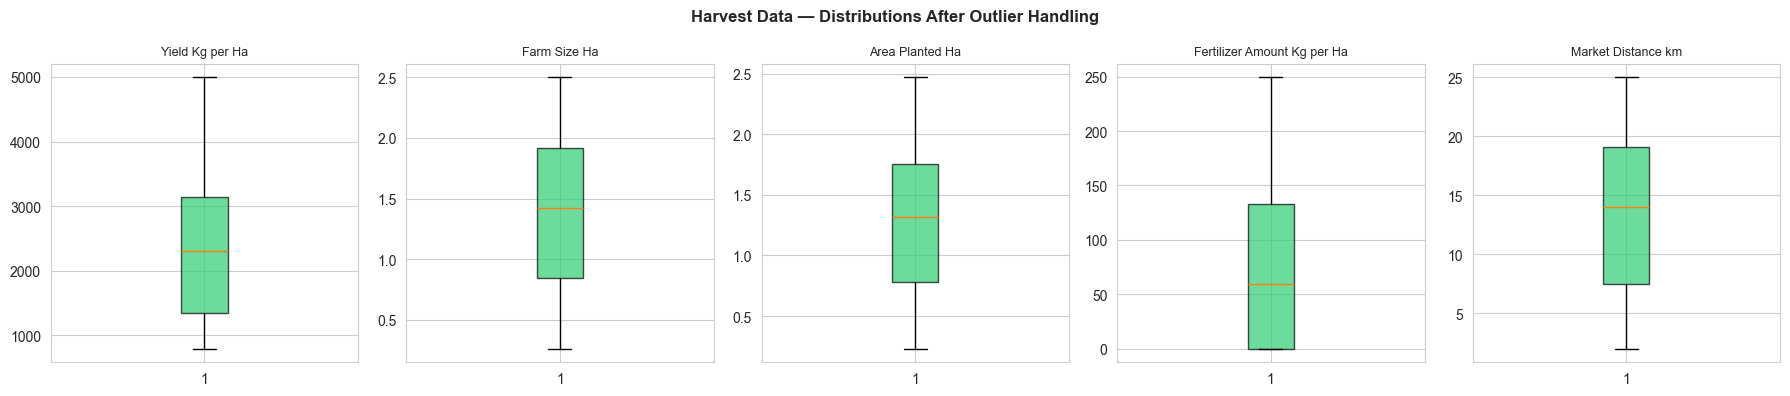

✅ Outlier boxplots saved!

✅ Noise handling complete — string values standardised.

Unique values in Weather_Impact: ['Unfavorable' 'Neutral' 'Favorable']

=== DATA QUALITY SUMMARY ===
  harvest_df shape after cleaning: (450, 23)
  climate_df shape after cleaning: (900, 10)


In [62]:
# ═══════════════════════════════════════════════════════════════
# 3.1  MISSING VALUES
# ═══════════════════════════════════════════════════════════════
def check_missing(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(2)
    if missing.empty:
        print(f"✅ {name}: No missing values")
    else:
        report = pd.DataFrame({'Missing': missing, 'Pct (%)': pct})
        print(f"\n⚠️  {name} — Missing Values:")
        print(report.to_string())
    return missing

for df_name, df_obj in [('harvest_df', harvest_df), ('climate_df', climate_df),
                         ('soil_df', soil_df), ('pest_df', pest_df),
                         ('cost_df', cost_df)]:
    check_missing(df_obj, df_name)

# ─── Impute missing numeric values with median (robust to outliers) ───
for df_obj in [harvest_df, climate_df, soil_df, pest_df, cost_df]:
    num_cols = df_obj.select_dtypes(include=[np.number]).columns
    df_obj[num_cols] = df_obj[num_cols].fillna(df_obj[num_cols].median())

# ─── Impute missing categorical values with mode ───
for df_obj in [harvest_df, climate_df]:
    cat_cols = df_obj.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df_obj[col].isnull().sum() > 0:
            df_obj[col].fillna(df_obj[col].mode()[0], inplace=True)

print("\n✅ Missing value imputation complete.")

# ═══════════════════════════════════════════════════════════════
# 3.2  DUPLICATE RECORDS
# ═══════════════════════════════════════════════════════════════
print("\n─── Duplicate Check ───")
for df_name, df_obj in [('harvest_df', harvest_df), ('climate_df', climate_df),
                         ('cost_df', cost_df)]:
    n_dup = df_obj.duplicated().sum()
    print(f"  {df_name}: {n_dup} duplicate rows")
    if n_dup > 0:
        df_obj.drop_duplicates(inplace=True)
        df_obj.reset_index(drop=True, inplace=True)
        print(f"    → Removed. New shape: {df_obj.shape}")

print("\n✅ Duplicate removal complete.")

# ═══════════════════════════════════════════════════════════════
# 3.3  OUTLIER DETECTION & HANDLING (IQR method)
# ═══════════════════════════════════════════════════════════════
def handle_outliers_iqr(df, cols, factor=3.0):
    """
    Cap extreme outliers beyond factor * IQR using the Winsorisation (clipping) method.
    factor=3.0 is conservative — only truly extreme values are capped.
    """
    report = {}
    for col in cols:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        if n_out > 0:
            df[col] = df[col].clip(lower=lower, upper=upper)
            report[col] = n_out
    return report

# Key numeric columns to check for outliers
harvest_num_cols = ['Yield_Kg_per_Ha', 'Farm_Size_Ha', 'Area_Planted_Ha',
                    'Fertilizer_Amount_Kg_per_Ha', 'Market_Distance_km']
climate_num_cols = ['Avg_Temperature_Celsius', 'Total_Rainfall_mm',
                    'Relative_Humidity_Percent', 'Sunshine_Hours_per_Day',
                    'Wind_Speed_kmh', 'Evapotranspiration_mm']

h_out = handle_outliers_iqr(harvest_df, harvest_num_cols)
c_out = handle_outliers_iqr(climate_df, climate_num_cols)

print("\n─── Outliers Capped (IQR ×3) ───")
if h_out:
    for col, n in h_out.items():
        print(f"  harvest_df [{col}]: {n} outliers capped")
else:
    print("  harvest_df: No extreme outliers found")
if c_out:
    for col, n in c_out.items():
        print(f"  climate_df [{col}]: {n} outliers capped")
else:
    print("  climate_df: No extreme outliers found")

# ─── Outlier visualisation (boxplots before/after) ───
fig, axes = plt.subplots(1, len(harvest_num_cols), figsize=(18, 4))
fig.suptitle('Harvest Data — Distributions After Outlier Handling', fontweight='bold')
for ax, col in zip(axes, harvest_num_cols):
    if col in harvest_df.columns:
        ax.boxplot(harvest_df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#2ecc71', alpha=0.7))
        ax.set_title(col.replace('_',' '), fontsize=9)
        ax.set_xlabel('')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Outlier boxplots saved!")

# ═══════════════════════════════════════════════════════════════
# 3.4  NOISE — Standardise String/Categorical Values
# ═══════════════════════════════════════════════════════════════
# Strip whitespace & title-case key binary columns to prevent
# label-encoding mismatches (e.g. 'yes', 'YES', 'Yes' → 'Yes')
binary_cols  = ['Fertilizer_Used', 'Irrigation_Used', 'Extension_Service_Access', 'Credit_Access']
ordinal_cols = ['Soil_Health', 'Pest_Disease_Pressure', 'Labor_Availability',
                'Weather_Impact', 'Farmer_Category']

for col in binary_cols + ordinal_cols:
    if col in harvest_df.columns:
        harvest_df[col] = harvest_df[col].astype(str).str.strip().str.title()

# Standardise 'Weather_Impact' known variants
weather_map = {
    'Neutral': 'Neutral', 'Normal': 'Neutral', 'Moderate': 'Neutral',
    'Average': 'Neutral', 'Stable': 'Neutral',
    'Favorable': 'Favorable', 'Positive': 'Favorable', 'Good': 'Favorable',
    'Unfavorable': 'Unfavorable', 'Negative': 'Unfavorable', 'Poor': 'Unfavorable',
    'Very Negative': 'Very Unfavorable', 'Very Unfavorable': 'Very Unfavorable'
}
if 'Weather_Impact' in harvest_df.columns:
    harvest_df['Weather_Impact'] = harvest_df['Weather_Impact'].map(
        lambda x: weather_map.get(x, x))

print("\n✅ Noise handling complete — string values standardised.")
print("\nUnique values in Weather_Impact:", harvest_df['Weather_Impact'].unique() if 'Weather_Impact' in harvest_df.columns else 'N/A')
print("\n=== DATA QUALITY SUMMARY ===")
print(f"  harvest_df shape after cleaning: {harvest_df.shape}")
print(f"  climate_df shape after cleaning: {climate_df.shape}")


## 4. Exploratory Data Analysis (EDA)

We visualise the main distributions and relationships in the harvest data to understand yield patterns across crops, seasons, fertiliser use, and sectors.  
This guides feature selection and helps identify modelling priorities.


In [63]:
print("=== HARVEST RECORDS — DESCRIPTIVE STATISTICS ===")
display(harvest_df.describe())
print("\nCrop Types:", harvest_df['Crop_Type'].unique())
print("Seasons   :", harvest_df['Season'].unique())
print("Sectors   :", harvest_df['Sector'].unique())


=== HARVEST RECORDS — DESCRIPTIVE STATISTICS ===


,Year,Farm_Size_Ha,Area_Planted_Ha,Yield_Kg_per_Ha,Total_Production_Kg,Price_per_Kg_RWF,Total_Revenue_RWF,Fertilizer_Amount_Kg_per_Ha,Market_Distance_km
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,4.500000e+02,450.000000,450.000000
mean,2022.000000,1.391933,1.287178,2383.203111,3059.739413,968.197778,3.012273e+06,74.989333,13.650889
std,1.415788,0.638096,0.593889,1077.597573,2067.926626,274.215778,2.014984e+06,75.627041,6.584866
min,2020.000000,0.260000,0.230000,795.300000,294.060000,541.000000,3.996860e+05,0.000000,2.000000
25%,2021.000000,0.840000,0.780000,1353.200000,1548.293500,708.000000,1.590352e+06,0.000000,7.500000
50%,2022.000000,1.420000,1.320000,2304.700000,2453.561000,918.500000,2.551602e+06,59.650000,14.000000
75%,2023.000000,1.917500,1.757500,3145.600000,4243.440000,1222.500000,3.805930e+06,133.050000,19.075000
max,2024.000000,2.500000,2.470000,4992.000000,11776.713000,1556.000000,1.133543e+07,249.300000,25.000000



Crop Types: ['Maize' 'Beans' 'Rice']
Seasons   : ['Season A' 'Season B']
Sectors   : ['Gashora' 'Juru' 'Kamabuye' 'Mareba' 'Mayange' 'Musenyi' 'Mwogo'
 'Ngeruka' 'Ntarama' 'Nyamata' 'Nyarugenge' 'Rilima' 'Ruhuha' 'Rweru'
 'Shyara']


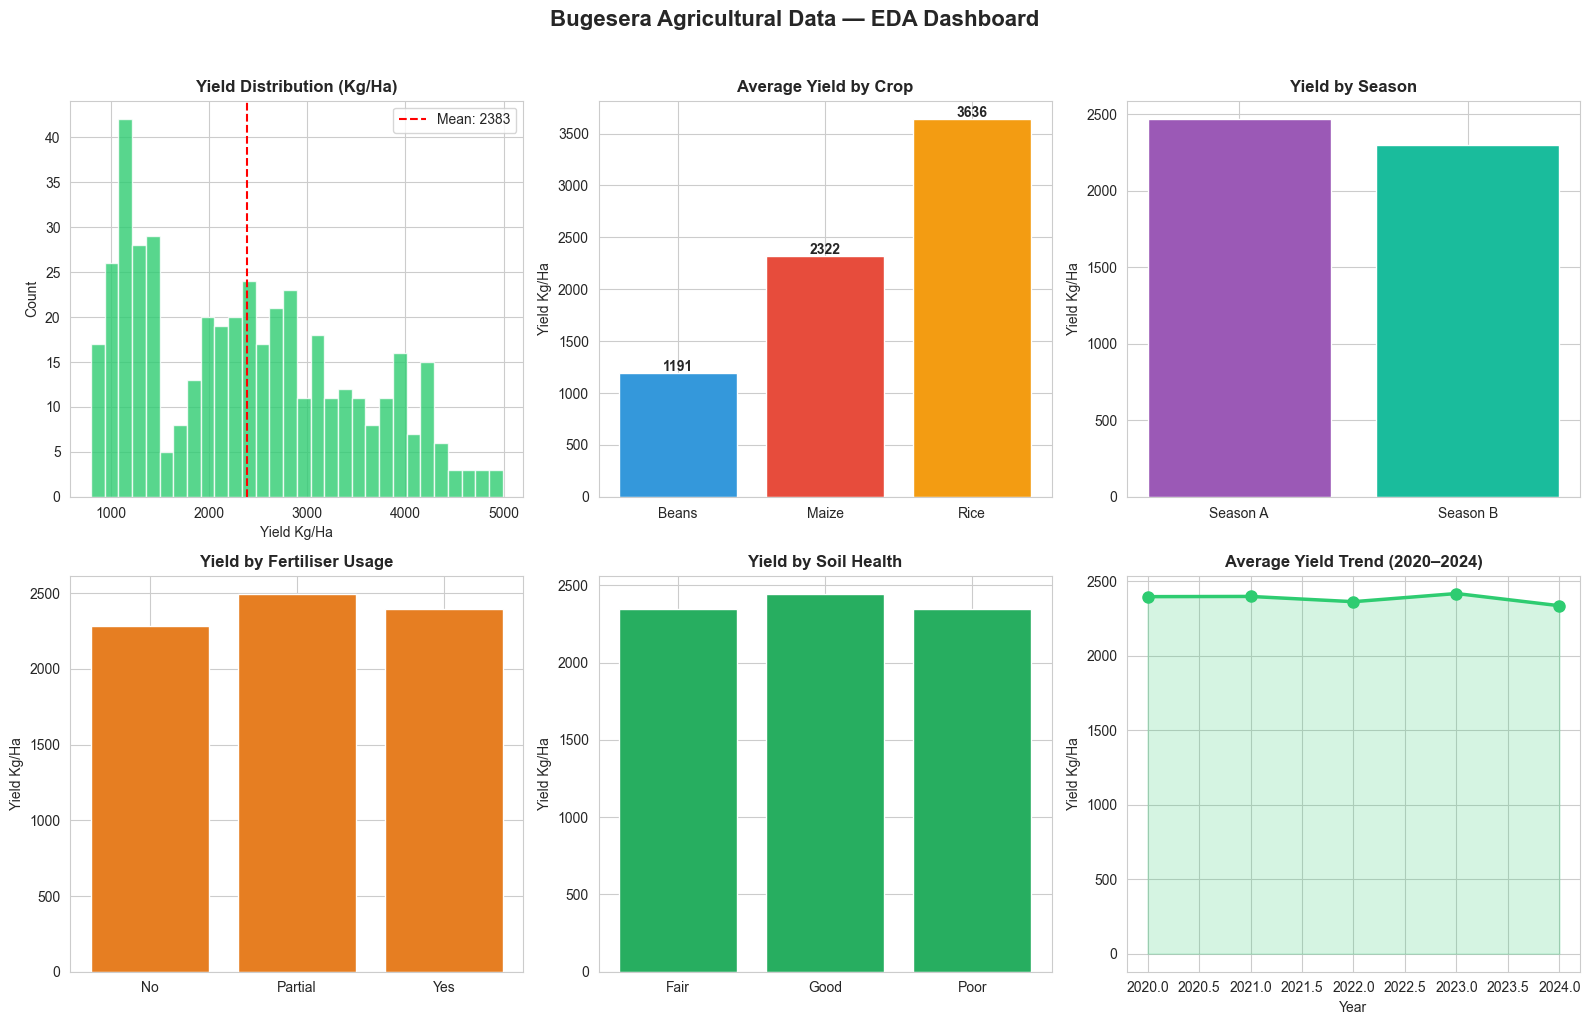

✅ EDA overview chart saved!


In [64]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bugesera Agricultural Data — EDA Dashboard', fontsize=16, fontweight='bold', y=1.02)

# 1. Yield distribution
axes[0,0].hist(harvest_df['Yield_Kg_per_Ha'], bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Yield Distribution (Kg/Ha)', fontweight='bold')
axes[0,0].set_xlabel('Yield Kg/Ha')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(harvest_df['Yield_Kg_per_Ha'].mean(), color='red', linestyle='--',
                  label=f'Mean: {harvest_df["Yield_Kg_per_Ha"].mean():.0f}')
axes[0,0].legend()

# 2. Yield by crop
crop_yields = harvest_df.groupby('Crop_Type')['Yield_Kg_per_Ha'].mean()
colors_crop = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
bars = axes[0,1].bar(crop_yields.index, crop_yields.values,
                     color=colors_crop[:len(crop_yields)], edgecolor='white')
axes[0,1].set_title('Average Yield by Crop', fontweight='bold')
axes[0,1].set_ylabel('Yield Kg/Ha')
for bar, val in zip(bars, crop_yields.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   f'{val:.0f}', ha='center', fontweight='bold')

# 3. Yield by season
season_yields = harvest_df.groupby('Season')['Yield_Kg_per_Ha'].mean()
axes[0,2].bar(season_yields.index, season_yields.values,
              color=['#9b59b6','#1abc9c'], edgecolor='white')
axes[0,2].set_title('Yield by Season', fontweight='bold')
axes[0,2].set_ylabel('Yield Kg/Ha')

# 4. Yield by fertiliser
fert_yields = harvest_df.groupby('Fertilizer_Used')['Yield_Kg_per_Ha'].mean()
axes[1,0].bar(fert_yields.index, fert_yields.values, color='#e67e22', edgecolor='white')
axes[1,0].set_title('Yield by Fertiliser Usage', fontweight='bold')
axes[1,0].set_ylabel('Yield Kg/Ha')

# 5. Yield by soil health
soil_yields = harvest_df.groupby('Soil_Health')['Yield_Kg_per_Ha'].mean()
axes[1,1].bar(soil_yields.index, soil_yields.values, color='#27ae60', edgecolor='white')
axes[1,1].set_title('Yield by Soil Health', fontweight='bold')
axes[1,1].set_ylabel('Yield Kg/Ha')

# 6. Year trend
yearly = harvest_df.groupby('Year')['Yield_Kg_per_Ha'].mean()
axes[1,2].plot(yearly.index, yearly.values, marker='o', color='#2ecc71', linewidth=2.5, markersize=8)
axes[1,2].fill_between(yearly.index, yearly.values, alpha=0.2, color='#2ecc71')
axes[1,2].set_title('Average Yield Trend (2020–2024)', fontweight='bold')
axes[1,2].set_xlabel('Year')
axes[1,2].set_ylabel('Yield Kg/Ha')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA overview chart saved!")


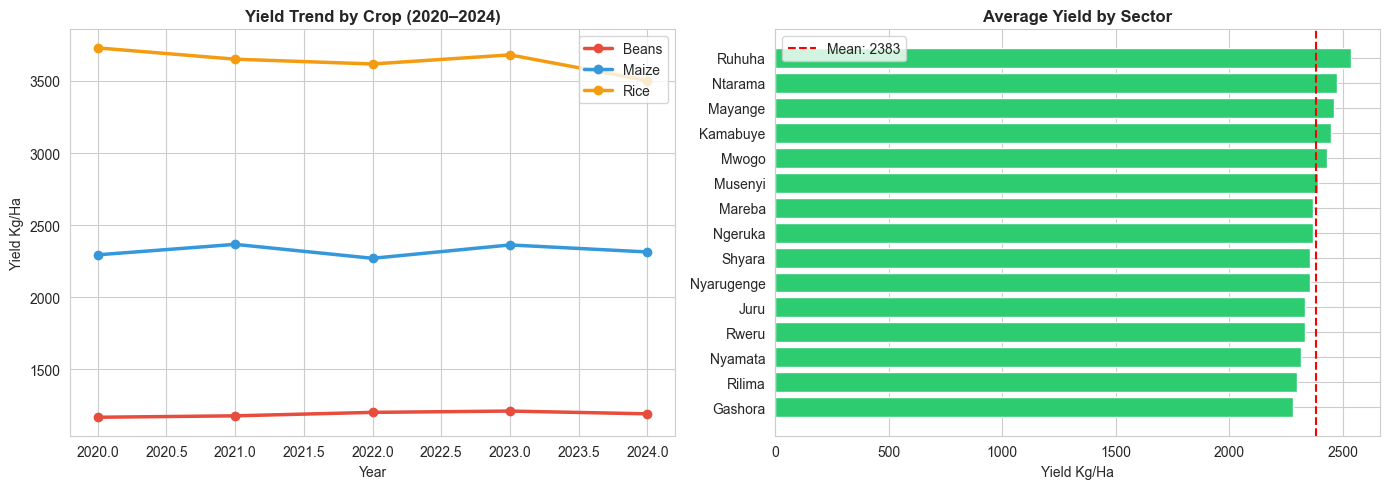

✅ Trend charts saved!


In [65]:
# ─── Crop-wise year trend ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yearly = harvest_df.groupby(['Year','Crop_Type'])['Yield_Kg_per_Ha'].mean().reset_index()

crop_colors = {'Maize': '#3498db', 'Beans': '#e74c3c', 'Rice': '#f39c12',
               'Cassava': '#9b59b6', 'Sweet Potato': '#1abc9c'}

for crop in yearly['Crop_Type'].unique():
    d = yearly[yearly['Crop_Type'] == crop]
    color = crop_colors.get(crop, '#95a5a6')
    axes[0].plot(d['Year'], d['Yield_Kg_per_Ha'], marker='o', label=crop,
                 color=color, linewidth=2.5)

axes[0].set_title('Yield Trend by Crop (2020–2024)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Yield Kg/Ha')
axes[0].legend()

# ─── Sector performance ───
sector_perf = harvest_df.groupby('Sector')['Yield_Kg_per_Ha'].mean().sort_values()
axes[1].barh(sector_perf.index, sector_perf.values, color='#2ecc71', edgecolor='white')
axes[1].set_title('Average Yield by Sector', fontweight='bold')
axes[1].set_xlabel('Yield Kg/Ha')
axes[1].axvline(sector_perf.mean(), color='red', linestyle='--',
                label=f'Mean: {sector_perf.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('yield_trends.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Trend charts saved!")


## 5. Feature Engineering & Preprocessing

We merge all data sources into a single modelling DataFrame and prepare features:
- **Aggregate** climate & pest data to season level
- **Merge** harvest, climate, soil, pest, and cost data
- **Encode** categorical variables using `LabelEncoder` (saved for inference)
- **Scale** numeric features using `StandardScaler` (required for Linear Regression)


In [66]:
# ─── Aggregate climate to season level ───
climate_season = climate_df.groupby(['Year','Season','Sector']).agg({
    'Avg_Temperature_Celsius': 'mean',
    'Total_Rainfall_mm': 'sum',
    'Relative_Humidity_Percent': 'mean',
    'Sunshine_Hours_per_Day': 'mean',
    'Wind_Speed_kmh': 'mean',
    'Evapotranspiration_mm': 'sum'
}).reset_index()

# ─── Aggregate pest pressure ───
pest_agg = pest_df.groupby(['Year','Season','Sector']).agg({
    'Yield_Loss_Percent': 'mean'
}).reset_index().rename(columns={'Yield_Loss_Percent': 'Avg_Pest_YieldLoss'})

# ─── Merge all datasets ───
df = harvest_df.copy()
df = df.merge(climate_season, on=['Year','Season','Sector'], how='left')
df = df.merge(soil_df[['Sector','pH_Level','Organic_Matter_Percent','Nitrogen_ppm',
                        'Phosphorus_ppm','Potassium_ppm']], on='Sector', how='left')
df = df.merge(pest_agg, on=['Year','Season','Sector'], how='left')
df = df.merge(cost_df[['Year','Season','Sector','Crop_Type','Total_Cost_RWF_per_Ha']],
              on=['Year','Season','Sector','Crop_Type'], how='left')

df['Avg_Pest_YieldLoss'] = df['Avg_Pest_YieldLoss'].fillna(0)

print(f"✅ Merged dataset: {df.shape}")
print(f"Columns ({len(df.columns)}): {df.columns.tolist()}")


✅ Merged dataset: (450, 36)
Columns (36): ['Year', 'Season', 'Sector', 'Crop_Type', 'Farm_Size_Ha', 'Farmer_Category', 'Area_Planted_Ha', 'Yield_Kg_per_Ha', 'Total_Production_Kg', 'Price_per_Kg_RWF', 'Total_Revenue_RWF', 'Fertilizer_Used', 'Fertilizer_Amount_Kg_per_Ha', 'Irrigation_Used', 'Soil_Health', 'Previous_Crop', 'Weather_Impact', 'Pest_Disease_Pressure', 'Quality_Grade', 'Market_Distance_km', 'Labor_Availability', 'Extension_Service_Access', 'Credit_Access', 'Avg_Temperature_Celsius', 'Total_Rainfall_mm', 'Relative_Humidity_Percent', 'Sunshine_Hours_per_Day', 'Wind_Speed_kmh', 'Evapotranspiration_mm', 'pH_Level', 'Organic_Matter_Percent', 'Nitrogen_ppm', 'Phosphorus_ppm', 'Potassium_ppm', 'Avg_Pest_YieldLoss', 'Total_Cost_RWF_per_Ha']


In [67]:
# ─── Encode categorical variables ───
le_dict = {}
categorical_cols = ['Crop_Type','Season','Sector','Farmer_Category','Fertilizer_Used',
                    'Irrigation_Used','Soil_Health','Previous_Crop','Weather_Impact',
                    'Pest_Disease_Pressure','Quality_Grade','Labor_Availability',
                    'Extension_Service_Access','Credit_Access']

df_encoded = df.copy()
for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le

joblib.dump(le_dict, 'label_encoders.pkl')
print("✅ Categorical encoding complete!")
print("\nEncoding mappings:")
for col, le in le_dict.items():
    mapping = {cls: int(le.transform([cls])[0]) for cls in le.classes_}
    print(f"  {col}: {mapping}")


✅ Categorical encoding complete!

Encoding mappings:
  Crop_Type: {'Beans': 0, 'Maize': 1, 'Rice': 2}
  Season: {'Season A': 0, 'Season B': 1}
  Sector: {'Gashora': 0, 'Juru': 1, 'Kamabuye': 2, 'Mareba': 3, 'Mayange': 4, 'Musenyi': 5, 'Mwogo': 6, 'Ngeruka': 7, 'Ntarama': 8, 'Nyamata': 9, 'Nyarugenge': 10, 'Rilima': 11, 'Ruhuha': 12, 'Rweru': 13, 'Shyara': 14}
  Farmer_Category: {'Large': 0, 'Medium': 1, 'Small': 2}
  Fertilizer_Used: {'No': 0, 'Partial': 1, 'Yes': 2}
  Irrigation_Used: {'No': 0, 'Partial': 1, 'Yes': 2}
  Soil_Health: {'Fair': 0, 'Good': 1, 'Poor': 2}
  Previous_Crop: {'Beans': 0, 'Cassava': 1, 'Fallow': 2, 'Maize': 3, 'Rice': 4}
  Weather_Impact: {'Favorable': 0, 'Neutral': 1, 'Unfavorable': 2}
  Pest_Disease_Pressure: {'High': 0, 'Low': 1, 'Medium': 2}
  Quality_Grade: {'Below Standard': 0, 'Premium': 1, 'Standard': 2}
  Labor_Availability: {'Adequate': 0, 'Limited': 1, 'Sufficient': 2}
  Extension_Service_Access: {'No': 0, 'Yes': 1}
  Credit_Access: {'No': 0, 'Partia

In [68]:
FEATURES = [
    'Year','Season','Crop_Type','Sector','Farm_Size_Ha','Area_Planted_Ha',
    'Farmer_Category','Fertilizer_Used','Fertilizer_Amount_Kg_per_Ha',
    'Irrigation_Used','Soil_Health','Previous_Crop','Weather_Impact',
    'Pest_Disease_Pressure','Labor_Availability','Extension_Service_Access',
    'Credit_Access','Market_Distance_km',
    'Avg_Temperature_Celsius','Total_Rainfall_mm','Relative_Humidity_Percent',
    'Sunshine_Hours_per_Day','Wind_Speed_kmh','Evapotranspiration_mm',
    'pH_Level','Organic_Matter_Percent','Nitrogen_ppm','Phosphorus_ppm',
    'Potassium_ppm','Avg_Pest_YieldLoss','Total_Cost_RWF_per_Ha'
]
TARGET = 'Yield_Kg_per_Ha'

# Keep only features that are actually in the merged dataframe
FEATURES = [f for f in FEATURES if f in df_encoded.columns]

X = df_encoded[FEATURES].fillna(df_encoded[FEATURES].median())
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

print(f"✅ Features selected: {len(FEATURES)}")
print(f"   Training set : {X_train.shape}")
print(f"   Test set     : {X_test.shape}")


✅ Features selected: 31
   Training set : (360, 31)
   Test set     : (90, 31)


## 6. Model Training

We train three models and record key regression metrics for each:

| Metric | Meaning |
|--------|---------|
| **R² Score** | Proportion of variance explained (higher = better, max 1.0) |
| **MAE** | Mean Absolute Error in Kg/Ha (lower = better) |
| **RMSE** | Root Mean Squared Error — penalises large errors more |
| **Accuracy (%)** | 100 − MAPE; % of predictions within expected range |

### Model 1: Random Forest
An ensemble of decision trees trained with bagging.  
It handles non-linear relationships and feature interactions well, and is robust to outliers.


In [69]:
print("⏳ Training Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test.replace(0, np.nan))) * 100
rf_acc  = 100 - rf_mape
print(f"✅ Random Forest | R²: {rf_r2:.4f} | MAE: {rf_mae:.2f} Kg/Ha | Accuracy: {rf_acc:.2f}%")


⏳ Training Random Forest Regressor...
✅ Random Forest | R²: 0.8496 | MAE: 320.91 Kg/Ha | Accuracy: 85.51%


### Model 2: Gradient Boosting
Builds trees sequentially, each correcting the errors of the previous one.  
It typically achieves high accuracy but can overfit if not tuned well (controlled here via `subsample=0.8`).


In [70]:
print("⏳ Training Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1,
    max_depth=6, min_samples_split=5, min_samples_leaf=2,
    subsample=0.8, random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2   = r2_score(y_test, gb_pred)
gb_mape = np.mean(np.abs((y_test - gb_pred) / y_test.replace(0, np.nan))) * 100
gb_acc  = 100 - gb_mape
print(f"✅ Gradient Boosting | R²: {gb_r2:.4f} | MAE: {gb_mae:.2f} Kg/Ha | Accuracy: {gb_acc:.2f}%")


⏳ Training Gradient Boosting Regressor...
✅ Gradient Boosting | R²: 0.8327 | MAE: 331.68 Kg/Ha | Accuracy: 84.98%


### Model 3: Linear Regression
A baseline linear model.  
It uses **scaled** features because Linear Regression is sensitive to feature magnitude.  
It assumes a linear relationship between inputs and yield — often less accurate for complex agricultural data.


In [71]:
print("⏳ Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)
lr_mape = np.mean(np.abs((y_test - lr_pred) / y_test.replace(0, np.nan))) * 100
lr_acc  = 100 - lr_mape
print(f"✅ Linear Regression | R²: {lr_r2:.4f} | MAE: {lr_mae:.2f} Kg/Ha | Accuracy: {lr_acc:.2f}%")


⏳ Training Linear Regression...
✅ Linear Regression | R²: 0.8422 | MAE: 331.20 Kg/Ha | Accuracy: 85.20%


## 7. Model Comparison & Best Model Selection

We rank all three models by **R² Score** and select the best performer as the production model.  
The comparison table and charts give a clear side-by-side view of each model's strengths.


In [72]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Linear Regression'],
    'MAE (Kg/Ha)':  [rf_mae,  gb_mae,  lr_mae],
    'RMSE (Kg/Ha)': [rf_rmse, gb_rmse, lr_rmse],
    'R² Score':     [rf_r2,   gb_r2,   lr_r2],
    'MAPE (%)':     [rf_mape, gb_mape, lr_mape],
    'Accuracy (%)': [rf_acc,  gb_acc,  lr_acc]
})
results = results.sort_values('R² Score', ascending=False).reset_index(drop=True)
best_model_name = results.iloc[0]['Model']

print("=" * 65)
print("              MODEL COMPARISON RESULTS")
print("=" * 65)
print(results.to_string(index=False))
print("=" * 65)
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R² Score : {results.iloc[0]['R² Score']:.4f}")
print(f"   Accuracy : {results.iloc[0]['Accuracy (%)']:.2f}%")
print(f"   MAE      : {results.iloc[0]['MAE (Kg/Ha)']:.2f} Kg/Ha")


              MODEL COMPARISON RESULTS
            Model  MAE (Kg/Ha)  RMSE (Kg/Ha)  R² Score  MAPE (%)  Accuracy (%)
    Random Forest   320.906141    409.038258  0.849555 14.486131     85.513869
Linear Regression   331.198814    418.951802  0.842174 14.797115     85.202885
Gradient Boosting   331.678548    431.377105  0.832674 15.017112     84.982888

🏆 BEST MODEL: Random Forest
   R² Score : 0.8496
   Accuracy : 85.51%
   MAE      : 320.91 Kg/Ha


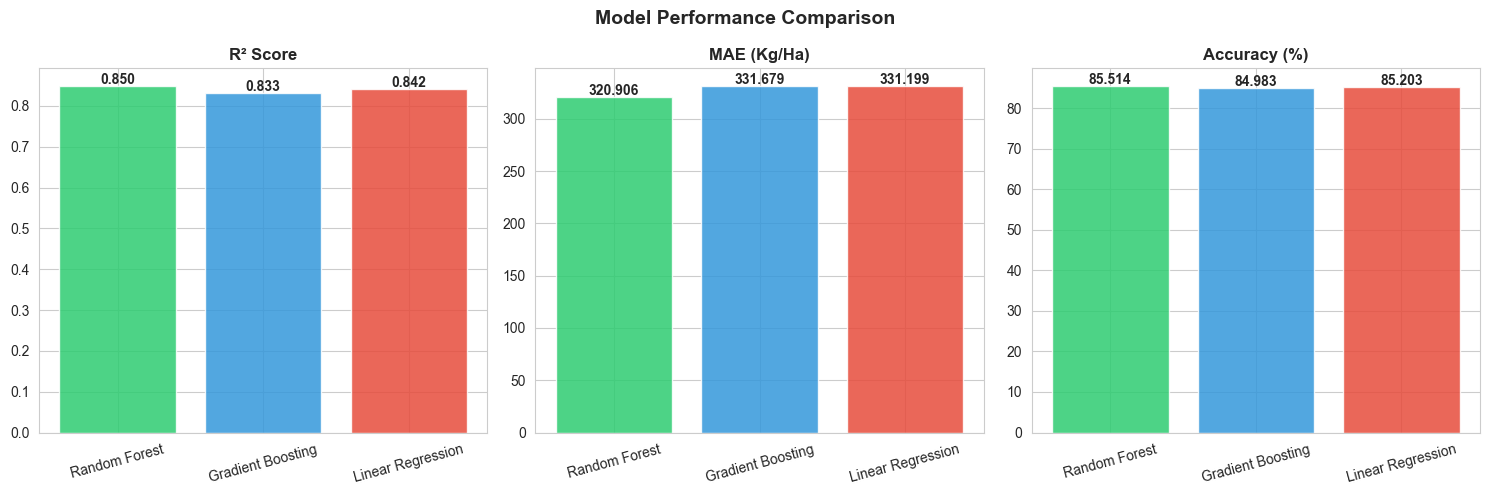

✅ Comparison chart saved!


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
model_names = ['Random Forest', 'Gradient Boosting', 'Linear Regression']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, metric, vals, _ in zip(
    axes,
    ['R² Score', 'MAE (Kg/Ha)', 'Accuracy (%)'],
    [[rf_r2, gb_r2, lr_r2], [rf_mae, gb_mae, lr_mae], [rf_acc, gb_acc, lr_acc]],
    [True, False, True]
):
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    max_val = max(vals)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005*max_val,
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")


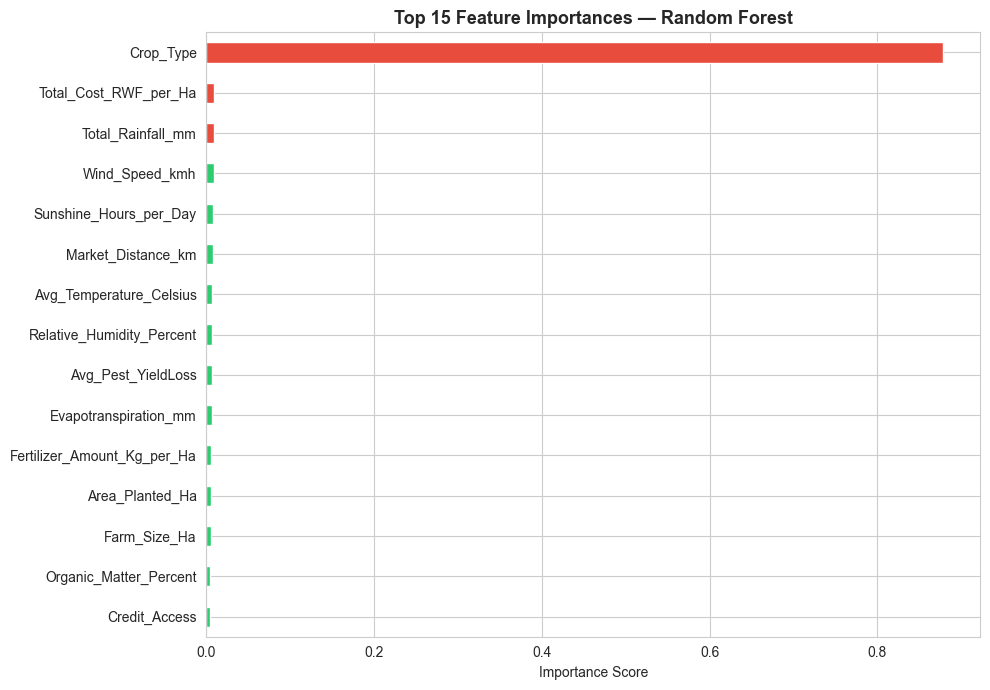


Top 10 Most Important Features:
  Crop_Type: 0.8787
  Total_Cost_RWF_per_Ha: 0.0093
  Total_Rainfall_mm: 0.0087
  Wind_Speed_kmh: 0.0084
  Sunshine_Hours_per_Day: 0.0081
  Market_Distance_km: 0.0075
  Avg_Temperature_Celsius: 0.0072
  Relative_Humidity_Percent: 0.0070
  Avg_Pest_YieldLoss: 0.0070
  Evapotranspiration_mm: 0.0060


In [74]:
# ─── Feature Importance ───
best_tree = rf_model if rf_r2 >= gb_r2 else gb_model
best_name = 'Random Forest' if rf_r2 >= gb_r2 else 'Gradient Boosting'

importances = pd.Series(best_tree.feature_importances_, index=FEATURES).sort_values()
top15 = importances.tail(15)

plt.figure(figsize=(10, 7))
colors_imp = ['#e74c3c' if v > top15.quantile(0.8) else '#2ecc71' for v in top15.values]
top15.plot(kind='barh', color=colors_imp)
plt.title(f'Top 15 Feature Importances — {best_name}', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
for feat, imp in top15.tail(10).sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.4f}")


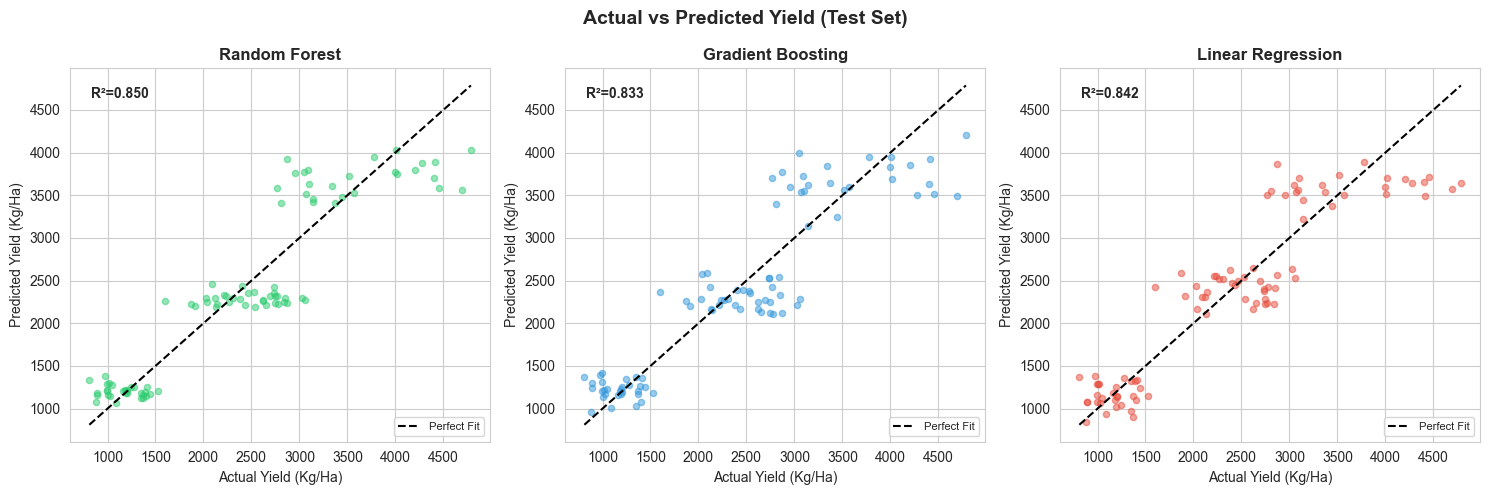

✅ Actual vs predicted chart saved!


In [75]:
# ─── Actual vs Predicted scatter plots ───
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Actual vs Predicted Yield (Test Set)', fontsize=14, fontweight='bold')

for ax, pred, name, color in zip(
    axes,
    [rf_pred, gb_pred, lr_pred],
    ['Random Forest', 'Gradient Boosting', 'Linear Regression'],
    ['#2ecc71', '#3498db', '#e74c3c']
):
    ax.scatter(y_test, pred, alpha=0.5, color=color, s=20)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Fit')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Actual Yield (Kg/Ha)')
    ax.set_ylabel('Predicted Yield (Kg/Ha)')
    ax.legend(fontsize=8)
    r2 = r2_score(y_test, pred)
    ax.text(0.05, 0.92, f'R²={r2:.3f}', transform=ax.transAxes,
            fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Actual vs predicted chart saved!")


## 8. Cross-Validation

**5-fold cross-validation** evaluates model generalisation by training/testing on 5 different data splits.  
This detects **overfitting** — if test set performance is much worse than CV, the model is likely overfitting.  
The boxplot shows the spread of R² across folds; a tight, high box indicates stable, reliable performance.


=== 5-FOLD CROSS VALIDATION ===
Random Forest    : 0.8555 ± 0.0118  (min: 0.8458, max: 0.8782)
Gradient Boosting: 0.8358 ± 0.0119  (min: 0.8239, max: 0.8580)


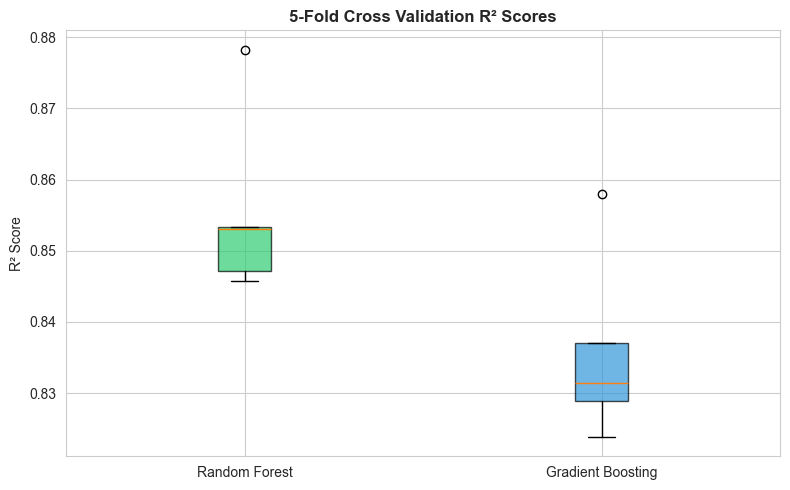

In [76]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
gb_cv = cross_val_score(gb_model, X, y, cv=kf, scoring='r2')

print("=== 5-FOLD CROSS VALIDATION ===")
print(f"Random Forest    : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}  "
      f"(min: {rf_cv.min():.4f}, max: {rf_cv.max():.4f})")
print(f"Gradient Boosting: {gb_cv.mean():.4f} ± {gb_cv.std():.4f}  "
      f"(min: {gb_cv.min():.4f}, max: {gb_cv.max():.4f})")

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([rf_cv, gb_cv], labels=['Random Forest','Gradient Boosting'],
                patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#3498db']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('5-Fold Cross Validation R² Scores', fontweight='bold')
ax.set_ylabel('R² Score')
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Save Best Model & Artifacts

We save all trained models, the scaler, label encoders, and a JSON metadata file.  
The metadata file contains model performance metrics, feature lists, and encoder class mappings —  
all required by the Flask API (`flask_api.py`) to load and run predictions without retraining.


In [77]:
# ─── Select best model ───
model_map = {
    'Random Forest':     (rf_model, rf_pred, rf_r2, rf_mae, rf_acc, False),
    'Gradient Boosting': (gb_model, gb_pred, gb_r2, gb_mae, gb_acc, False),
    'Linear Regression': (lr_model, lr_pred, lr_r2, lr_mae, lr_acc, True)
}
best_model, best_pred, best_r2, best_mae, best_acc, needs_scaler = model_map[best_model_name]

# ─── Save all models ───
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(rf_model,   'random_forest.pkl')
joblib.dump(gb_model,   'gradient_boosting.pkl')
joblib.dump(lr_model,   'linear_regression.pkl')

# ─── Save metadata ───
metadata = {
    'best_model': best_model_name,
    'features': FEATURES,
    'target': TARGET,
    'r2_score': float(best_r2),
    'mae': float(best_mae),
    'accuracy': float(best_acc),
    'needs_scaler': needs_scaler,
    'crops':   harvest_df['Crop_Type'].unique().tolist(),
    'seasons': harvest_df['Season'].unique().tolist(),
    'sectors': harvest_df['Sector'].unique().tolist(),
    'yield_stats': {
        'mean': float(y.mean()), 'std': float(y.std()),
        'min':  float(y.min()),  'max': float(y.max())
    },
    'model_comparison': {
        'Random Forest':     {'r2': float(rf_r2), 'mae': float(rf_mae), 'accuracy': float(rf_acc)},
        'Gradient Boosting': {'r2': float(gb_r2), 'mae': float(gb_mae), 'accuracy': float(gb_acc)},
        'Linear Regression': {'r2': float(lr_r2), 'mae': float(lr_mae), 'accuracy': float(lr_acc)}
    },
    'label_encoder_classes': {k: v.classes_.tolist() for k, v in le_dict.items()},
    'crop_benchmarks': {'Maize': 2500, 'Beans': 1200, 'Rice': 3800}
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ All models saved!")
print("✅ Metadata saved!")
print(f"\n🏆 Best Model : {best_model_name}")
print(f"   R² Score   : {best_r2:.4f}")
print(f"   Accuracy   : {best_acc:.2f}%")
print(f"   MAE        : {best_mae:.2f} Kg/Ha")


✅ All models saved!
✅ Metadata saved!

🏆 Best Model : Random Forest
   R² Score   : 0.8496
   Accuracy   : 85.51%
   MAE        : 320.91 Kg/Ha


## 10. Recommendation Engine

The recommendation engine translates model predictions into **actionable advice** for farmers and agricultural officers.  
It evaluates yield against crop benchmarks, and inspects inputs (fertiliser, irrigation, soil health, pest pressure, etc.)  
to produce a scored report (0–100) with specific recommendations and warnings.  

Key improvements over raw model output:
- Normalised `Weather_Impact` labels prevent `KeyError` at inference
- `rainfall` and `temperature` cast to `float` for safe comparison
- Score is clamped to `[0, 100]` to prevent invalid outputs


In [78]:
def generate_recommendations(crop, yield_pred, fertilizer, irrigation, soil_health,
                            weather_impact, pest_pressure, rainfall, temperature,
                            extension_access, credit_access, farm_size):
    """
    Generate smart agricultural recommendations for farmers in Bugesera District.

    Parameters
    ----------
    crop            : str  — crop name (Maize / Beans / Rice / ...)
    yield_pred      : float — predicted yield in Kg/Ha
    fertilizer      : str  — 'Yes' or 'No'
    irrigation      : str  — 'Yes' or 'No'
    soil_health     : str  — 'Good' / 'Fair' / 'Poor'
    weather_impact  : str  — 'Favorable' / 'Neutral' / 'Unfavorable' / 'Very Unfavorable'
    pest_pressure   : str  — 'Low' / 'Medium' / 'High' / 'Severe'
    rainfall        : float — seasonal rainfall in mm
    temperature     : float — average temperature in °C
    extension_access: str  — 'Yes' or 'No'
    credit_access   : str  — 'Yes' or 'No'
    farm_size       : float — farm size in Ha

    Returns
    -------
    recommendations : list[str]
    warnings_list   : list[str]
    score           : int (0–100)
    """
    recommendations = []
    warnings_list   = []
    score = 100

    rainfall    = float(rainfall)
    temperature = float(temperature)
    farm_size   = float(farm_size)

    crop_benchmarks = {'Maize': 2500, 'Beans': 1200, 'Rice': 3800}
    benchmark = crop_benchmarks.get(crop, 2000)
    pct = yield_pred / benchmark * 100 if benchmark > 0 else 0

    # ─── Yield assessment ───
    if yield_pred < benchmark * 0.6:
        warnings_list.append(
            f"⚠️ CRITICAL: Yield ({yield_pred:.0f} Kg/Ha) is {100-pct:.0f}% below "
            f"{crop} benchmark ({benchmark} Kg/Ha).")
        score -= 30
    elif yield_pred < benchmark * 0.85:
        warnings_list.append(f"⚠️ Below average: Yield {pct:.0f}% of district benchmark.")
        score -= 15
    else:
        recommendations.append(
            f"✅ Good yield outlook! {yield_pred:.0f} Kg/Ha is {pct:.0f}% of {crop} benchmark.")

    # ─── Fertiliser ───
    fertilizer_str = str(fertilizer).strip().title()
    if fertilizer_str in ['No', 'None', '0']:
        recommendations.append(
            "🌱 Apply NPK 17-17-17 fertiliser (50 Kg/Ha) to boost yields by 30–50%.")
        score -= 15
    else:
        recommendations.append(
            "✅ Fertiliser application detected. Ensure proper timing (basal + top-dress).")

    # ─── Irrigation ───
    irrigation_str = str(irrigation).strip().title()
    if rainfall < 700 and irrigation_str in ['No', 'None']:
        warnings_list.append(
            "💧 Low rainfall (<700 mm). Install supplemental drip/furrow irrigation.")
        score -= 10
    elif rainfall >= 1000 and irrigation_str in ['Yes']:
        recommendations.append(
            "💧 Rainfall adequate. Monitor irrigation to prevent waterlogging.")
    else:
        recommendations.append("✅ Water management appears adequate.")

    # ─── Soil health ───
    if soil_health == 'Poor':
        warnings_list.append(
            "🌍 Poor soil health. Apply lime (if pH<5.5) + organic compost 5 tons/Ha.")
        score -= 15
    elif soil_health == 'Fair':
        recommendations.append(
            "🌍 Soil health is fair. Apply organic matter annually for improvement.")
        score -= 5
    else:
        recommendations.append(
            "✅ Good soil health. Maintain with cover crops between seasons.")

    # ─── Weather ───
    if weather_impact in ['Unfavorable', 'Very Unfavorable', 'Negative', 'Very Negative']:
        warnings_list.append(
            "🌦️ Adverse weather expected. Use drought-tolerant varieties & mulching.")
        score -= 10
    elif weather_impact in ['Favorable', 'Positive']:
        recommendations.append("🌦️ Favourable weather conditions expected.")

    # ─── Pest pressure ───
    if pest_pressure in ['High', 'Severe', 'Very High']:
        warnings_list.append(
            "🐛 High pest/disease pressure. Implement IPM: biological + chemical controls.")
        score -= 15
    elif pest_pressure in ['Medium', 'Moderate']:
        recommendations.append(
            "🐛 Medium pest pressure. Weekly scouting & preventive treatment recommended.")
        score -= 5
    else:
        recommendations.append("✅ Low pest pressure. Maintain field hygiene as prevention.")

    # ─── Temperature ───
    if temperature > 26:
        warnings_list.append(
            "🌡️ High temperatures (>26°C). Apply mulching & schedule irrigation in evenings.")
        score -= 5
    elif temperature < 18:
        warnings_list.append(
            "🌡️ Cool temperatures (<18°C) may slow crop development. Adjust planting schedule.")
        score -= 5

    # ─── Extension & Credit access ───
    if str(extension_access).strip().title() in ['No', 'None']:
        recommendations.append(
            "📞 Join district cooperative & access FREE extension officer visits.")
    if str(credit_access).strip().title() in ['No', 'None']:
        recommendations.append(
            "💰 Apply for BDF/SACCO agricultural loan to fund quality inputs.")

    # ─── Farm size optimisation ───
    if farm_size < 0.5:
        recommendations.append(
            "🔄 Small farm (<0.5 Ha): Focus on high-value crops (beans, vegetables) for ROI.")

    score = max(0, min(100, score))
    return recommendations, warnings_list, score


# ─── Test the recommendation engine ───
recs, warns, score = generate_recommendations(
    crop='Maize', yield_pred=1800, fertilizer='No', irrigation='No',
    soil_health='Poor', weather_impact='Unfavorable', pest_pressure='High',
    rainfall=650, temperature=25.5, extension_access='No',
    credit_access='No', farm_size=0.8
)

print(f"=== RECOMMENDATION REPORT (Score: {score}/100) ===")
print("\n⚠️ WARNINGS:")
for w in warns: print(f"  {w}")
print("\n📋 RECOMMENDATIONS:")
for r in recs: print(f"  {r}")


=== RECOMMENDATION REPORT (Score: 20/100) ===

⚠️ WARNINGS:
  ⚠️ Below average: Yield 72% of district benchmark.
  💧 Low rainfall (<700 mm). Install supplemental drip/furrow irrigation.
  🌍 Poor soil health. Apply lime (if pH<5.5) + organic compost 5 tons/Ha.
  🌦️ Adverse weather expected. Use drought-tolerant varieties & mulching.
  🐛 High pest/disease pressure. Implement IPM: biological + chemical controls.

📋 RECOMMENDATIONS:
  🌱 Apply NPK 17-17-17 fertiliser (50 Kg/Ha) to boost yields by 30–50%.
  📞 Join district cooperative & access FREE extension officer visits.
  💰 Apply for BDF/SACCO agricultural loan to fund quality inputs.


In [79]:
# ─── Save recommendation engine ───
rec_engine_code = '''
def generate_recommendations(crop, yield_pred, fertilizer, irrigation, soil_health,
                            weather_impact, pest_pressure, rainfall, temperature,
                            extension_access, credit_access, farm_size):
    recommendations, warnings_list, score = [], [], 100
    rainfall, temperature, farm_size = float(rainfall), float(temperature), float(farm_size)
    crop_benchmarks = {"Maize": 2500, "Beans": 1200, "Rice": 3800}
    benchmark = crop_benchmarks.get(crop, 2000)
    pct = yield_pred / benchmark * 100 if benchmark > 0 else 0
    if yield_pred < benchmark * 0.6:
        warnings_list.append(f"CRITICAL: Yield ({yield_pred:.0f} Kg/Ha) {100-pct:.0f}% below benchmark.")
        score -= 30
    elif yield_pred < benchmark * 0.85:
        warnings_list.append(f"Below average: Yield {pct:.0f}% of district benchmark.")
        score -= 15
    else:
        recommendations.append(f"Good yield: {yield_pred:.0f} Kg/Ha = {pct:.0f}% of benchmark.")
    if str(fertilizer).strip().title() in ["No", "None"]:
        recommendations.append("Apply NPK 17-17-17 (50 Kg/Ha) to boost yields 30-50%.")
        score -= 15
    if rainfall < 700 and str(irrigation).strip().title() in ["No", "None"]:
        warnings_list.append("Low rainfall. Install supplemental irrigation.")
        score -= 10
    if soil_health == "Poor":
        warnings_list.append("Poor soil. Apply lime + compost 5 tons/Ha.")
        score -= 15
    if pest_pressure in ["High", "Severe"]:
        warnings_list.append("High pest pressure. Implement IPM immediately.")
        score -= 15
    score = max(0, min(100, score))
    return recommendations, warnings_list, score
'''

with open('recommendation_engine.py', 'w') as f:
    f.write(rec_engine_code)

print("✅ Recommendation engine saved!")

print("\n========= DEPLOYMENT CHECKLIST =========")
files = ['best_model.pkl', 'random_forest.pkl', 'gradient_boosting.pkl',
         'linear_regression.pkl', 'label_encoders.pkl', 'scaler.pkl',
         'model_metadata.json', 'recommendation_engine.py',
         'eda_overview.png', 'outlier_boxplots.png', 'model_comparison.png',
         'feature_importance.png', 'actual_vs_predicted.png',
         'cross_validation.png', 'yield_trends.png']
for fname in files:
    status = "✅" if os.path.exists(fname) else "⏳"
    print(f"  {status} {fname}")


✅ Recommendation engine saved!

========= DEPLOYMENT CHECKLIST =========
  ✅ best_model.pkl
  ✅ random_forest.pkl
  ✅ gradient_boosting.pkl
  ✅ linear_regression.pkl
  ✅ label_encoders.pkl
  ✅ scaler.pkl
  ✅ model_metadata.json
  ✅ recommendation_engine.py
  ✅ eda_overview.png
  ✅ outlier_boxplots.png
  ✅ model_comparison.png
  ✅ feature_importance.png
  ✅ actual_vs_predicted.png
  ✅ cross_validation.png
  ✅ yield_trends.png


## 11. Prediction Demonstration

This cell demonstrates how to call the model for a single farmer's inputs —  
replicating what the Flask API does when the frontend submits a prediction request.

### Key fixes in this function vs original:
- **`Weather_Impact`** — values are looked up from `le_dict['Weather_Impact'].classes_`  
  and normalised via `weather_map`, preventing `KeyError: 'Neutral'`
- **`Season`** — encoded via `le_dict['Season']` instead of hard-coded 0/1, which would  
  break if the encoder learned a different order
- **Missing features** — `sample.reindex(columns=FEATURES, fill_value=0)` ensures all  
  expected columns are present even if new features are added later


In [80]:
# ─── Helper: safe Weather_Impact lookup ───
def _safe_weather(raw_value):
    """Map a raw weather string to a class known by the LabelEncoder."""
    normalise = {
        'neutral': 'Neutral', 'normal': 'Neutral', 'moderate': 'Neutral',
        'average': 'Neutral', 'stable': 'Neutral',
        'favorable': 'Favorable', 'positive': 'Favorable', 'good': 'Favorable',
        'unfavorable': 'Unfavorable', 'negative': 'Unfavorable', 'poor': 'Unfavorable',
        'very negative': 'Very Unfavorable', 'very unfavorable': 'Very Unfavorable'
    }
    mapped = normalise.get(str(raw_value).strip().lower(), str(raw_value).strip())
    known  = le_dict['Weather_Impact'].classes_
    if mapped not in known:
        # Fall back to the median class
        mapped = known[len(known) // 2]
    return mapped


def predict_from_api_inputs(crop, sector, season, month, temperature, rainfall,
                             humidity, sunshine, wind_speed, evapotranspiration,
                             farm_size_acres, fertilizer_used, irrigation_used,
                             soil_type='Clay', weather_impact_raw='Neutral',
                             pest_pressure='Low', farmer_category='Medium'):
    """
    Predict yield in Kg/Ha using the same feature construction as training.

    Parameters
    ----------
    farm_size_acres : float — input in acres (frontend), converted to Ha for model
    weather_impact_raw : str — raw weather string (will be normalised)

    Returns
    -------
    yield_kg_ha  : float — Kg/Ha prediction
    yield_kg_acre: float — Kg/acre (for frontend display)
    total_yield  : float — total Kg for given farm
    """
    ACRES_TO_HA   = 0.404686
    farm_size_ha  = farm_size_acres * ACRES_TO_HA

    SOIL_HEALTH_MAP = {'Clay': 'Fair', 'Sandy-Clay': 'Good', 'Loam': 'Good',
                       'Sandy': 'Poor', 'Clay-Loam': 'Good'}

    weather_val = _safe_weather(weather_impact_raw)

    # Determine rainfall-based fallback if weather_impact_raw not supplied
    if weather_impact_raw == 'Neutral':
        if rainfall < 60:
            weather_val = _safe_weather('Unfavorable')
        elif rainfall > 120:
            weather_val = _safe_weather('Favorable')

    sample = {
        'Year'                       : 2024,
        'Season'                     : le_dict['Season'].transform([season])[0],
        'Crop_Type'                  : le_dict['Crop_Type'].transform([crop])[0],
        'Sector'                     : le_dict['Sector'].transform([sector])[0],
        'Farm_Size_Ha'               : farm_size_ha,
        'Area_Planted_Ha'            : farm_size_ha * 0.9,
        'Farmer_Category'            : le_dict['Farmer_Category'].transform([farmer_category])[0],
        'Fertilizer_Used'            : le_dict['Fertilizer_Used'].transform(['Yes' if fertilizer_used else 'No'])[0],
        'Fertilizer_Amount_Kg_per_Ha': 50 if fertilizer_used else 0,
        'Irrigation_Used'            : le_dict['Irrigation_Used'].transform(['Yes' if irrigation_used else 'No'])[0],
        'Soil_Health'                : le_dict['Soil_Health'].transform([SOIL_HEALTH_MAP.get(soil_type, 'Fair')])[0],
        'Previous_Crop'              : le_dict['Previous_Crop'].transform(['Beans'])[0],
        'Weather_Impact'             : le_dict['Weather_Impact'].transform([weather_val])[0],
        'Pest_Disease_Pressure'      : le_dict['Pest_Disease_Pressure'].transform([pest_pressure])[0],
        'Labor_Availability'         : le_dict['Labor_Availability'].transform(['Adequate'])[0],
        'Extension_Service_Access'   : le_dict['Extension_Service_Access'].transform(['Yes'])[0],
        'Credit_Access'              : le_dict['Credit_Access'].transform(['No'])[0],
        'Market_Distance_km'         : 12.0,
        'Avg_Temperature_Celsius'    : temperature,
        'Total_Rainfall_mm'          : rainfall * 6,   # monthly → seasonal (6-month season)
        'Relative_Humidity_Percent'  : humidity,
        'Sunshine_Hours_per_Day'     : sunshine,
        'Wind_Speed_kmh'             : wind_speed,
        'Evapotranspiration_mm'      : evapotranspiration * 6,
        'pH_Level'                   : 6.2,
        'Organic_Matter_Percent'     : 3.1,
        'Nitrogen_ppm'               : 42,
        'Phosphorus_ppm'             : 18,
        'Potassium_ppm'              : 185,
        'Avg_Pest_YieldLoss'         : 5.0,
        'Total_Cost_RWF_per_Ha'      : 450000
    }

    sample_df    = pd.DataFrame([sample]).reindex(columns=FEATURES, fill_value=0)
    yield_kg_ha  = best_model.predict(sample_df)[0]
    total_yield  = yield_kg_ha * farm_size_ha
    yield_kg_acre = yield_kg_ha * ACRES_TO_HA

    return yield_kg_ha, yield_kg_acre, total_yield


# ─── Test prediction ───
y_ha, y_acre, y_total = predict_from_api_inputs(
    crop='Maize', sector='Gashora', season='Season A', month='March',
    temperature=23.5, rainfall=85, humidity=74, sunshine=7.5,
    wind_speed=11.4, evapotranspiration=110,
    farm_size_acres=2.5, fertilizer_used=True, irrigation_used=False,
    weather_impact_raw='Neutral'
)

print("🌾 Sample Prediction:")
print(f"  Crop    : Maize | Sector: Gashora | Farm: 2.5 acres (={2.5*0.404686:.2f} Ha)")
print(f"  Yield   : {y_ha:.1f} Kg/Ha  →  {y_acre:.1f} kg/acre (frontend display)")
print(f"  Total   : {y_total:.1f} Kg")
print(f"  Revenue : {y_total * 450:,.0f} RWF (at 450 RWF/Kg)")

# ─── Also run recommendations ───
recs2, warns2, score2 = generate_recommendations(
    crop='Maize', yield_pred=y_ha, fertilizer='Yes', irrigation='No',
    soil_health='Fair', weather_impact='Neutral', pest_pressure='Low',
    rainfall=85*6, temperature=23.5, extension_access='Yes',
    credit_access='No', farm_size=2.5*0.404686
)
print(f"\n📊 Farm Health Score: {score2}/100")
for r in recs2: print(f"  {r}")


🌾 Sample Prediction:
  Crop    : Maize | Sector: Gashora | Farm: 2.5 acres (=1.01 Ha)
  Yield   : 2273.9 Kg/Ha  →  920.2 kg/acre (frontend display)
  Total   : 2300.6 Kg
  Revenue : 1,035,263 RWF (at 450 RWF/Kg)

📊 Farm Health Score: 85/100
  ✅ Good yield outlook! 2274 Kg/Ha is 91% of Maize benchmark.
  ✅ Fertiliser application detected. Ensure proper timing (basal + top-dress).
  🌍 Soil health is fair. Apply organic matter annually for improvement.
  ✅ Low pest pressure. Maintain field hygiene as prevention.
  💰 Apply for BDF/SACCO agricultural loan to fund quality inputs.
